# Table of contents

# Configuration

In [1]:
import sys
from pathlib import Path

def _lab_root() -> Path:
  start = Path.cwd().resolve()
  for d in [start, *start.parents]:
    if (d / "pyproject.toml").is_file() and (d / "code" / "data" / "load_data.py").is_file():
      return d
  raise RuntimeError("Run ``%cd`` to your lab-2 folder (the one with pyproject.toml), then re-run this cell.")

lab_root = _lab_root()
sys.path.insert(0, str(lab_root / "code"))
print(f"Lab root: {lab_root}")
print(f"Added to sys.path: {lab_root / 'code'}")

Lab root: E:\hcmus\semester-6\csc14005-introduction-to-machine-learning\lab-2
Added to sys.path: E:\hcmus\semester-6\csc14005-introduction-to-machine-learning\lab-2\code


In [2]:
import importlib

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from data.load_data import load_dataset
from models.lle import LLE
from models.laplacian_eigen import LaplacianEigenmaps
import utils

importlib.reload(utils)
from utils import plot_embedding_scatter

In [3]:
SEED = 42

def set_seed(seed: int = SEED):
  np.random.seed(seed)

set_seed()

# Load datasets

## Circles

In [4]:
circles = load_dataset("circles")
circles_X, circles_y = circles.X, circles.y
print(circles_X.shape, circles_y.shape)

(1000, 2) (1000,)


## Swiss roll

In [5]:
swiss_roll = load_dataset("swiss_roll")
swiss_roll_X, swiss_roll_y = swiss_roll.X, swiss_roll.y
print(swiss_roll_X.shape, swiss_roll_y.shape)

(1500, 3) (1500,)


## Coil-20

In [6]:
coil20 = load_dataset("coil20")
coil20_X, coil20_y = coil20.X, coil20.y
print(coil20_X.shape, coil20_y.shape)

(1440, 16384) (1440,)


## MNIST

In [7]:
mnist = load_dataset("mnist")
mnist_X, mnist_y = mnist.X, mnist.y
print(mnist_X.shape, mnist_y.shape)

(70000, 784) (70000,)


In [8]:
mnist_sample_size = 10_000
mnist_sample_rng = np.random.default_rng(SEED)
mnist_sample_idx = mnist_sample_rng.choice(len(mnist_X), size=mnist_sample_size, replace=False)
mnist_X_sample = mnist_X[mnist_sample_idx]
mnist_y_sample = mnist_y[mnist_sample_idx]

# Dimensionality reduction

## PCA

## KPCA

## LLE

In [9]:
lle_model = LLE(
  n_neighbors=12, 
  n_components=2, 
  reg=1e-3
)

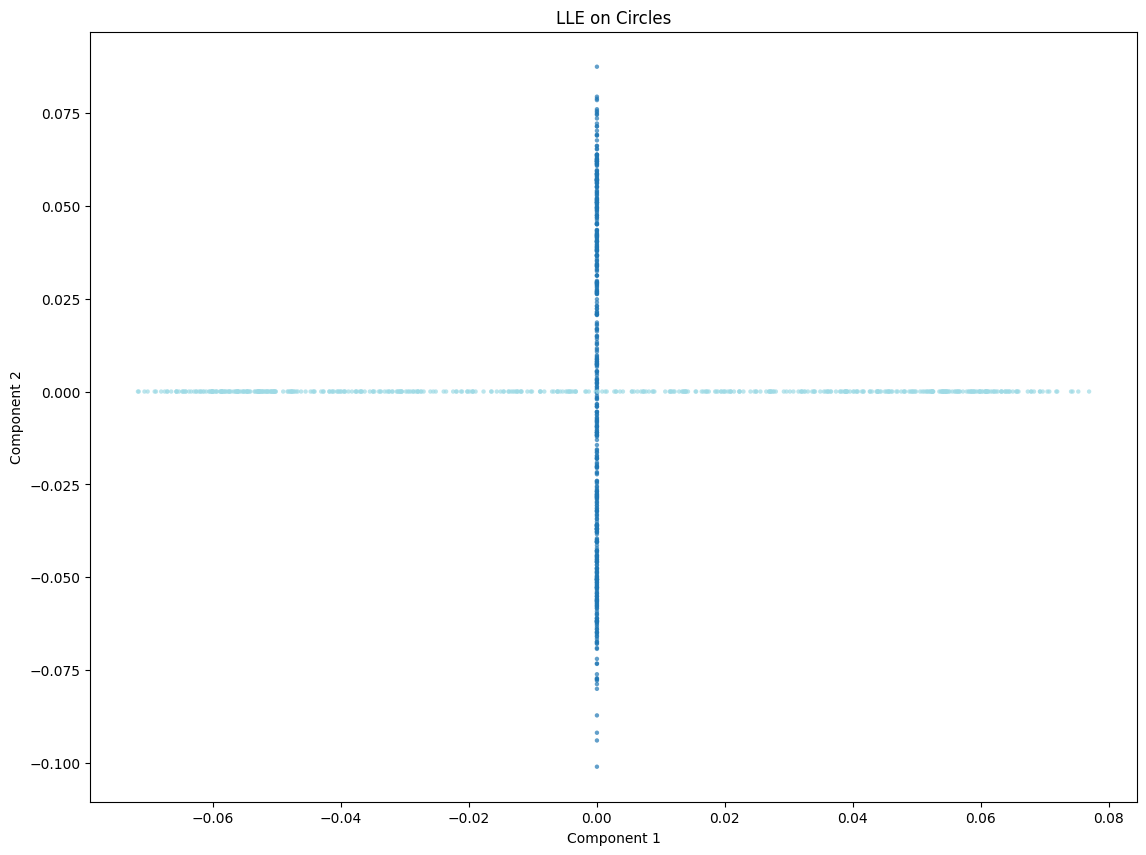

<Axes: title={'center': 'LLE on Circles'}, xlabel='Component 1', ylabel='Component 2'>

In [10]:
circles_X_2d_lle = lle_model.fit_transform(circles_X)
plot_embedding_scatter(circles_X_2d_lle, circles_y, title="LLE on Circles", s=10, alpha=0.7)

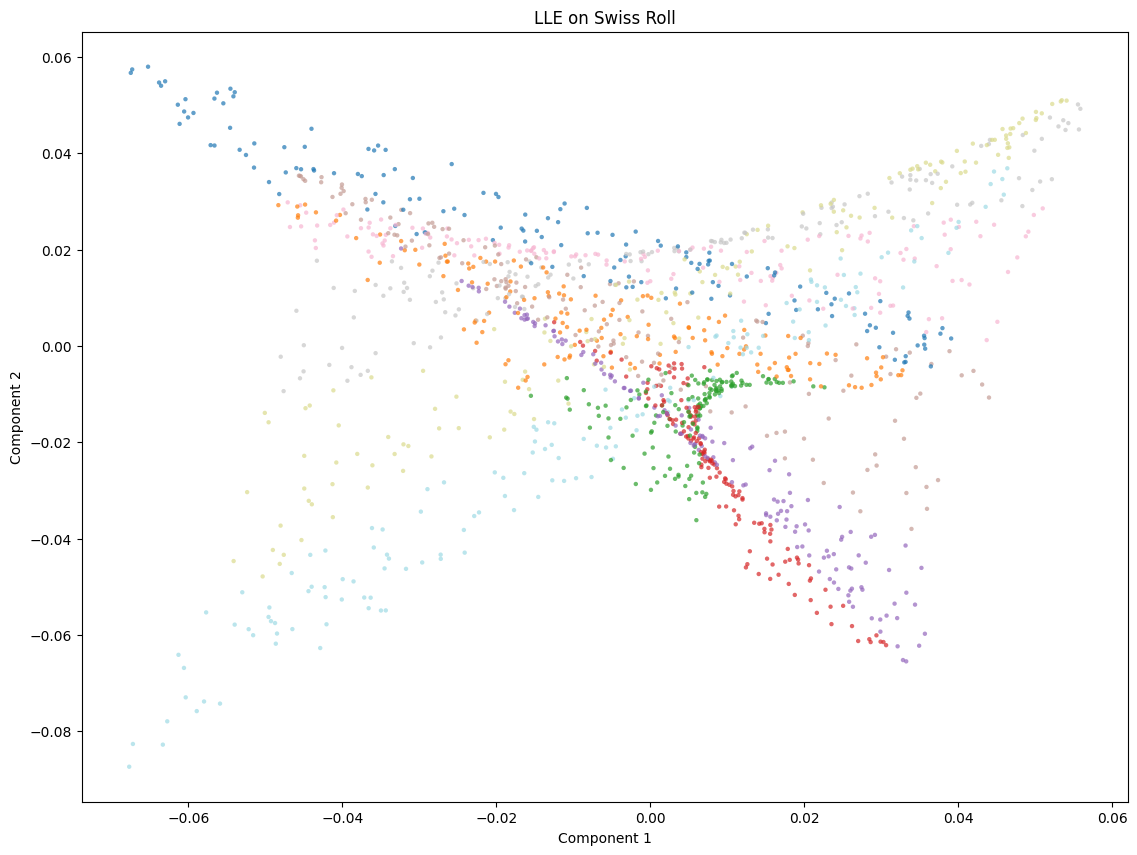

<Axes: title={'center': 'LLE on Swiss Roll'}, xlabel='Component 1', ylabel='Component 2'>

In [11]:
swiss_roll_X_2d_lle = lle_model.fit_transform(swiss_roll_X)
plot_embedding_scatter(swiss_roll_X_2d_lle, swiss_roll_y, title="LLE on Swiss Roll", s=10, alpha=0.7)

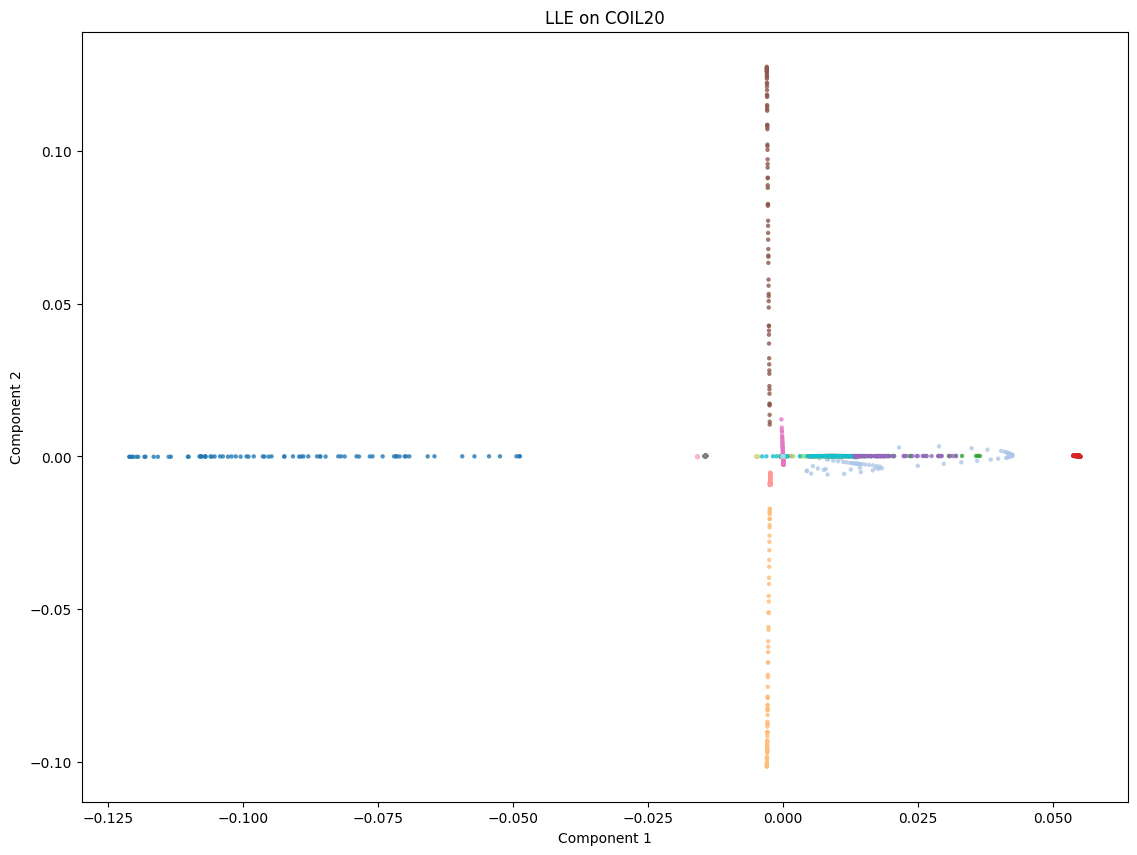

<Axes: title={'center': 'LLE on COIL20'}, xlabel='Component 1', ylabel='Component 2'>

In [12]:
coil20_X_2d_lle = lle_model.fit_transform(coil20_X)
plot_embedding_scatter(coil20_X_2d_lle, coil20_y, title="LLE on COIL20", s=10)

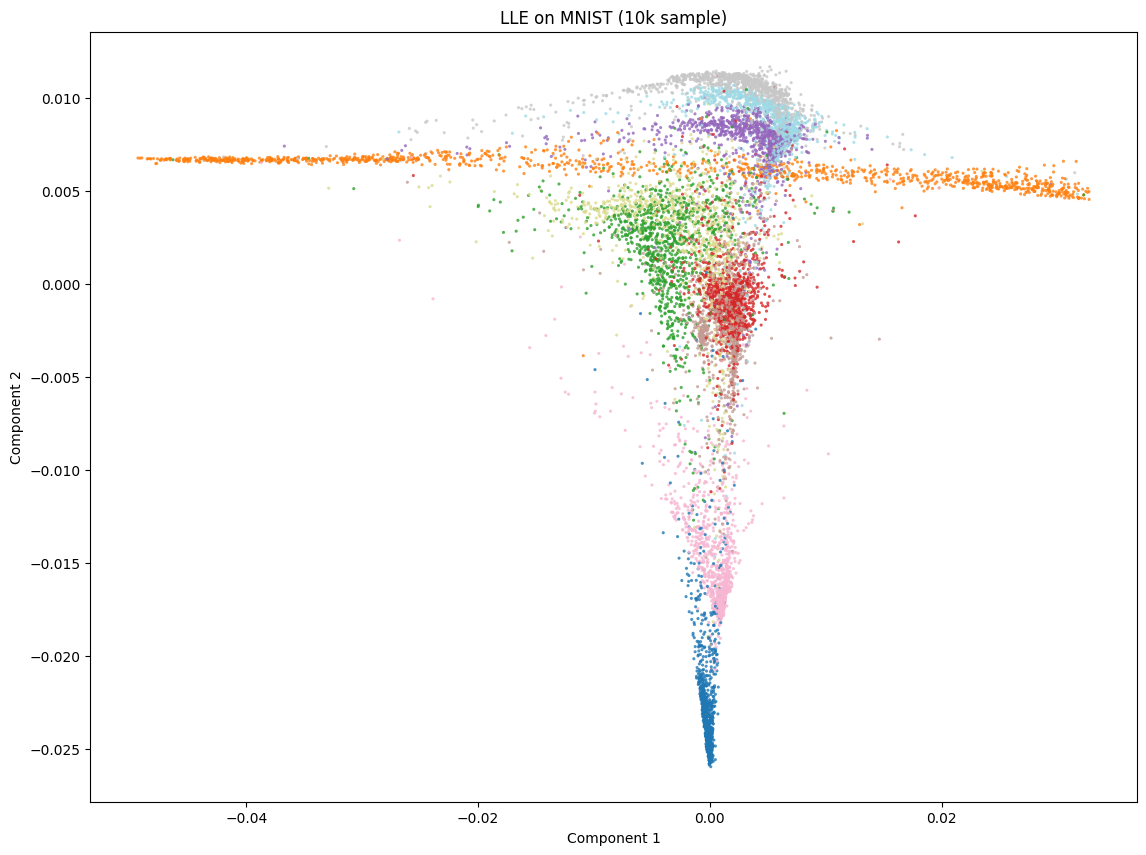

<Axes: title={'center': 'LLE on MNIST (10k sample)'}, xlabel='Component 1', ylabel='Component 2'>

In [13]:
mnist_X_2d_lle = lle_model.fit_transform(mnist_X_sample)
plot_embedding_scatter(mnist_X_2d_lle, mnist_y_sample, title="LLE on MNIST (10k sample)", s=5)

## Laplacian Eigenmaps

In [14]:
laplacian_model = LaplacianEigenmaps(
  n_neighbors=15, 
  n_components=2, 
  sigma=5.0
)

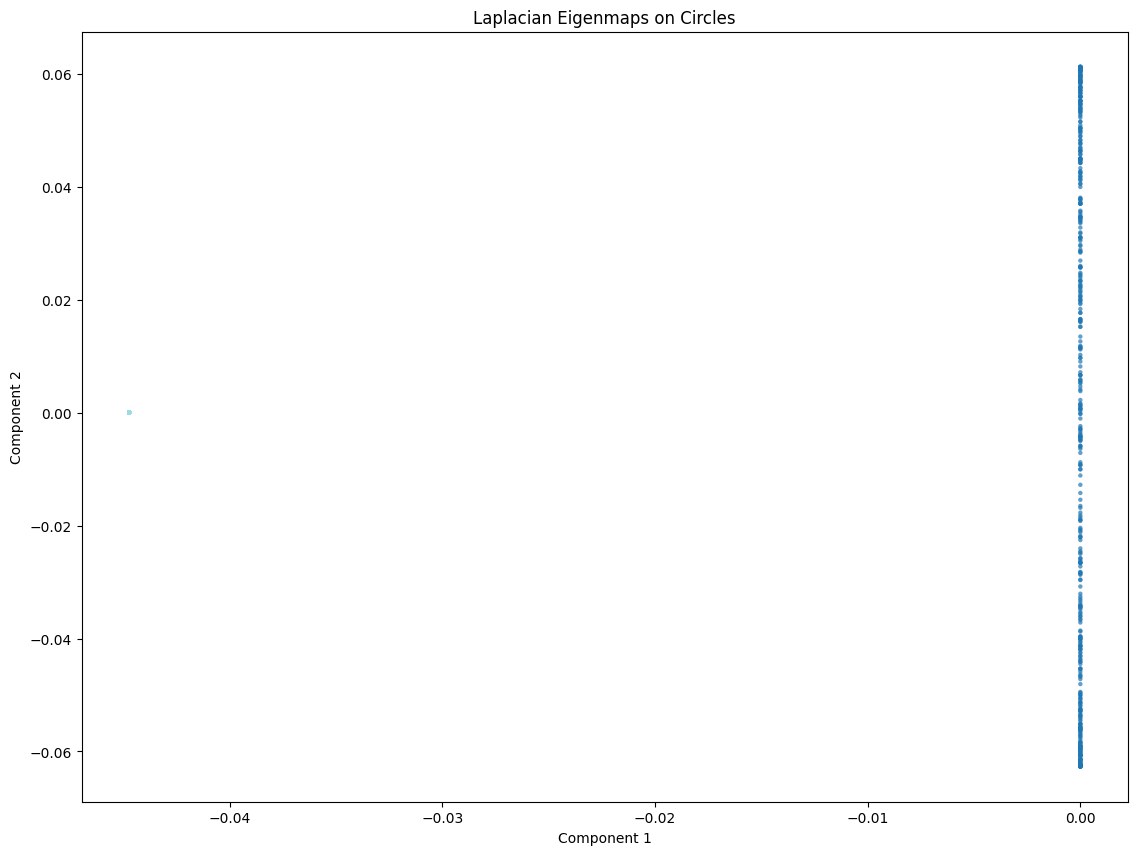

<Axes: title={'center': 'Laplacian Eigenmaps on Circles'}, xlabel='Component 1', ylabel='Component 2'>

In [15]:
circles_X_2d_le = laplacian_model.fit_transform(circles_X)
plot_embedding_scatter(circles_X_2d_le, circles_y, title="Laplacian Eigenmaps on Circles", s=10, alpha=0.7)

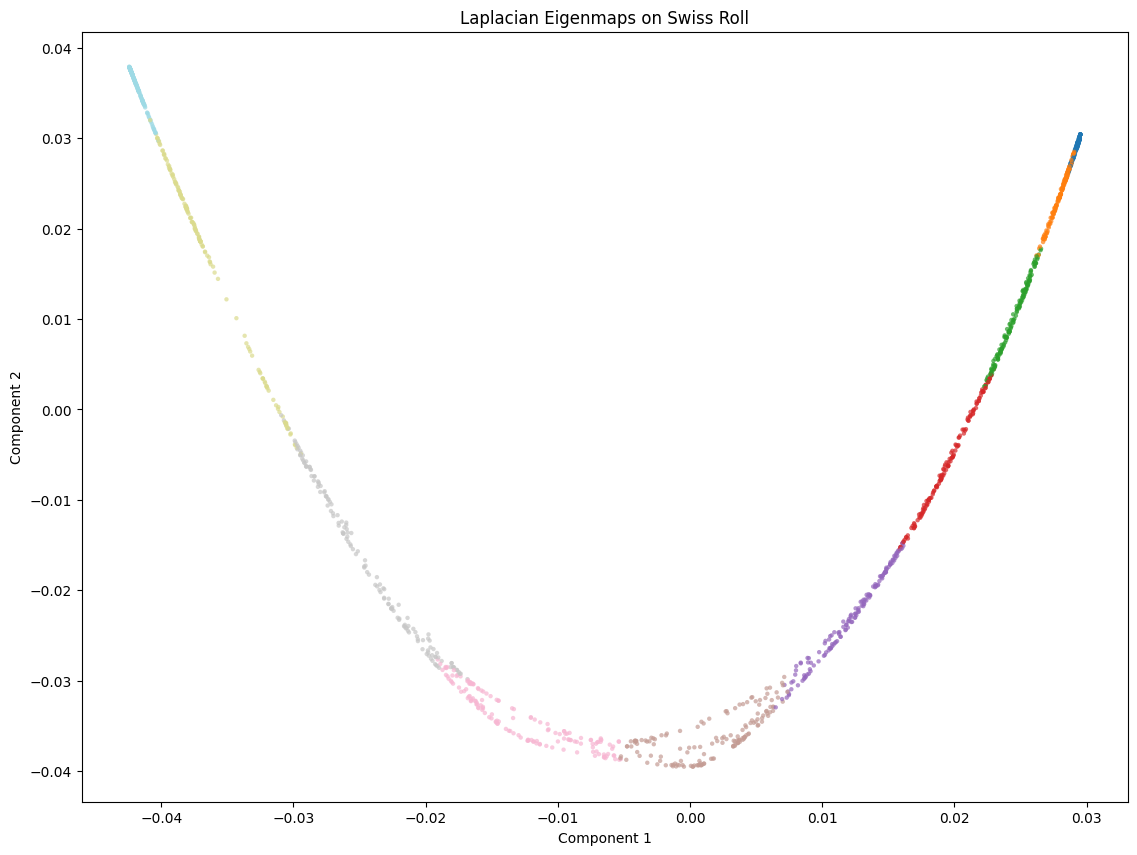

<Axes: title={'center': 'Laplacian Eigenmaps on Swiss Roll'}, xlabel='Component 1', ylabel='Component 2'>

In [16]:
swiss_roll_X_2d_le = laplacian_model.fit_transform(swiss_roll_X)
plot_embedding_scatter(swiss_roll_X_2d_le, swiss_roll_y, title="Laplacian Eigenmaps on Swiss Roll", s=10, alpha=0.7)

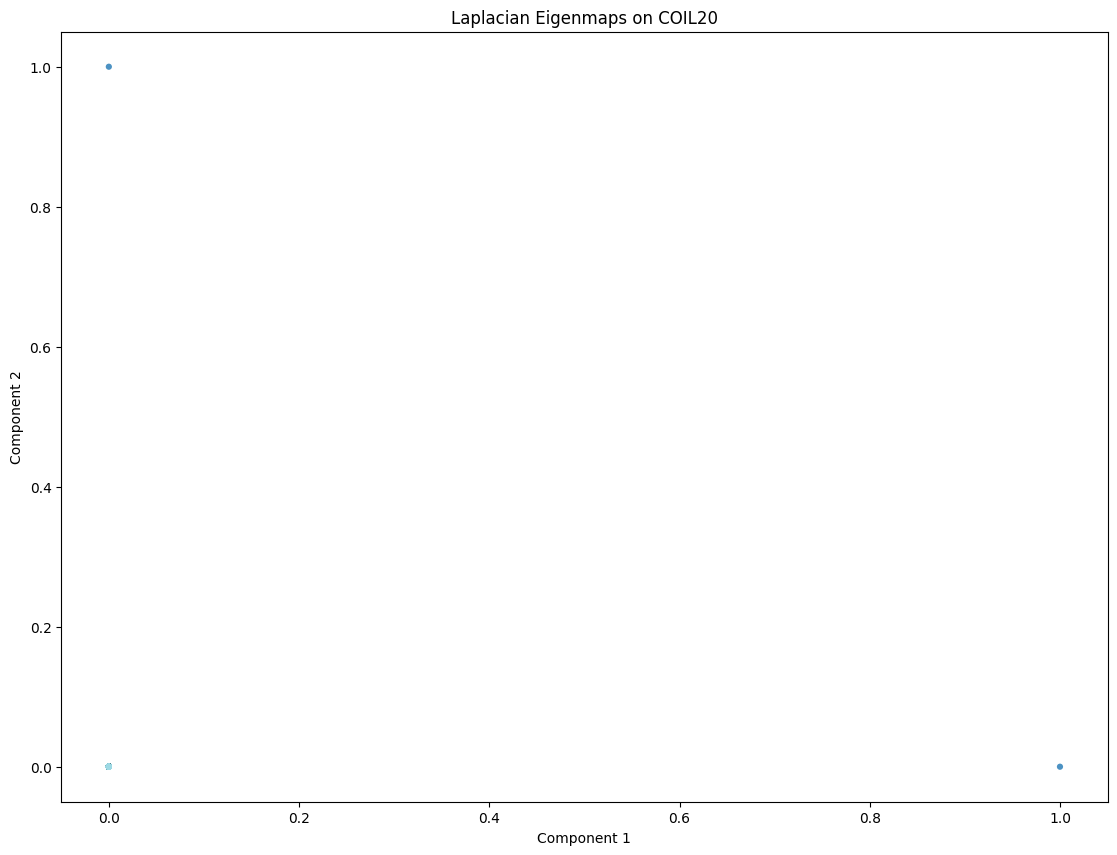

<Axes: title={'center': 'Laplacian Eigenmaps on COIL20'}, xlabel='Component 1', ylabel='Component 2'>

In [17]:
coil20_X_2d_le = laplacian_model.fit_transform(coil20_X)
plot_embedding_scatter(coil20_X_2d_le, coil20_y, title="Laplacian Eigenmaps on COIL20", s=20)

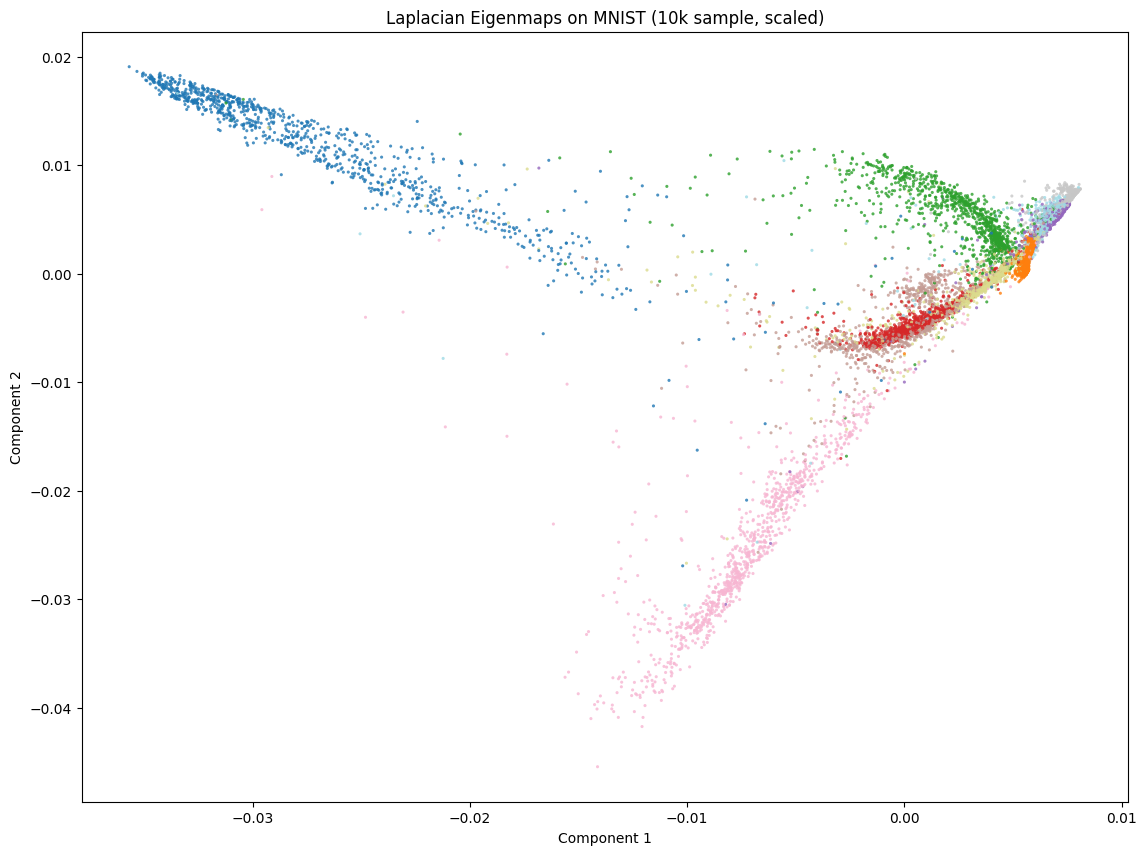

<Axes: title={'center': 'Laplacian Eigenmaps on MNIST (10k sample, scaled)'}, xlabel='Component 1', ylabel='Component 2'>

In [18]:
mnist_X_sample_scaled = mnist_X_sample / 255.0
mnist_X_2d_le = laplacian_model.fit_transform(mnist_X_sample_scaled)
plot_embedding_scatter(mnist_X_2d_le, mnist_y_sample, title="Laplacian Eigenmaps on MNIST (10k sample, scaled)", s=5)

## t-SNE

## UMAP

In [19]:
from umap import UMAP

umap_model = UMAP(
  n_neighbors=15,
  min_dist=0.1,
  n_components=2,
  metric='euclidean',
  random_state=SEED
)

e:\hcmus\semester-6\csc14005-introduction-to-machine-learning\lab-2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


e:\hcmus\semester-6\csc14005-introduction-to-machine-learning\lab-2\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


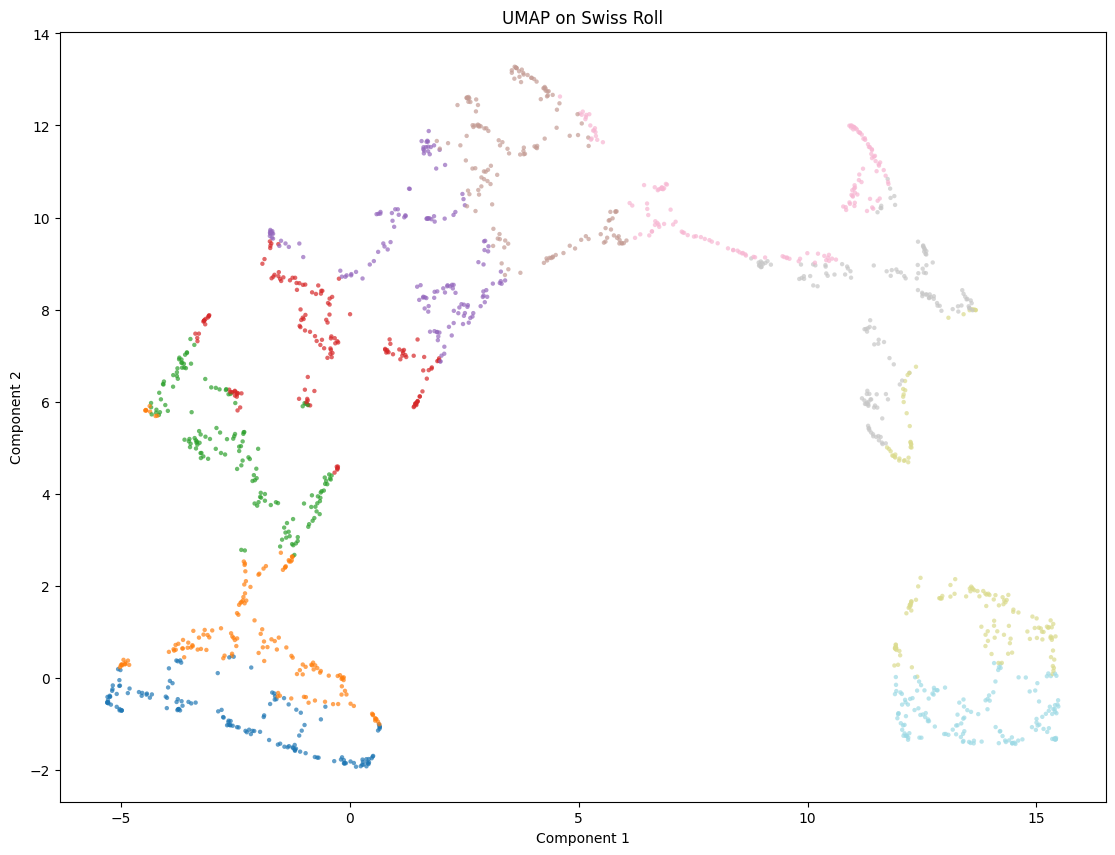

<Axes: title={'center': 'UMAP on Swiss Roll'}, xlabel='Component 1', ylabel='Component 2'>

In [20]:
swiss_roll_2d = umap_model.fit_transform(swiss_roll_X)
plot_embedding_scatter(swiss_roll_2d, swiss_roll_y, title="UMAP on Swiss Roll", s=10, alpha=0.7)

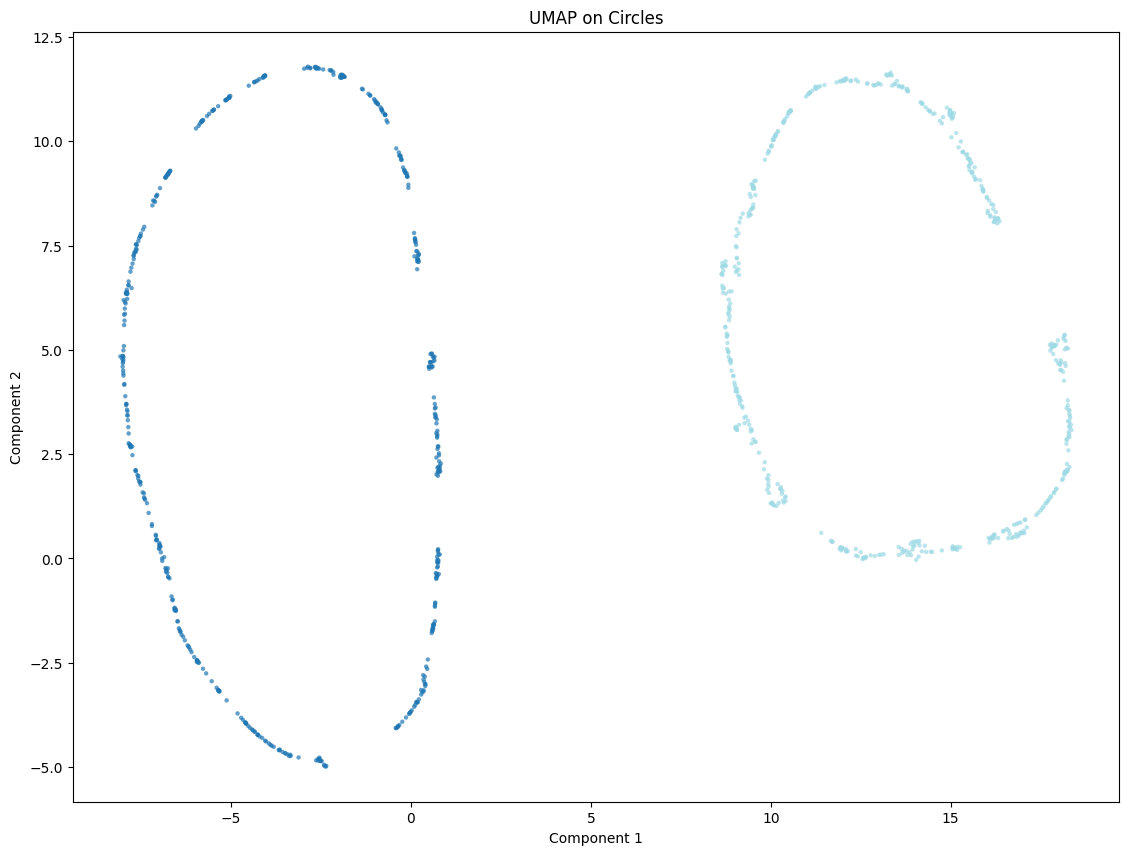

<Axes: title={'center': 'UMAP on Circles'}, xlabel='Component 1', ylabel='Component 2'>

In [21]:
circles_2d = umap_model.fit_transform(circles_X)
plot_embedding_scatter(circles_2d, circles_y, title="UMAP on Circles", s=10, alpha=0.7)

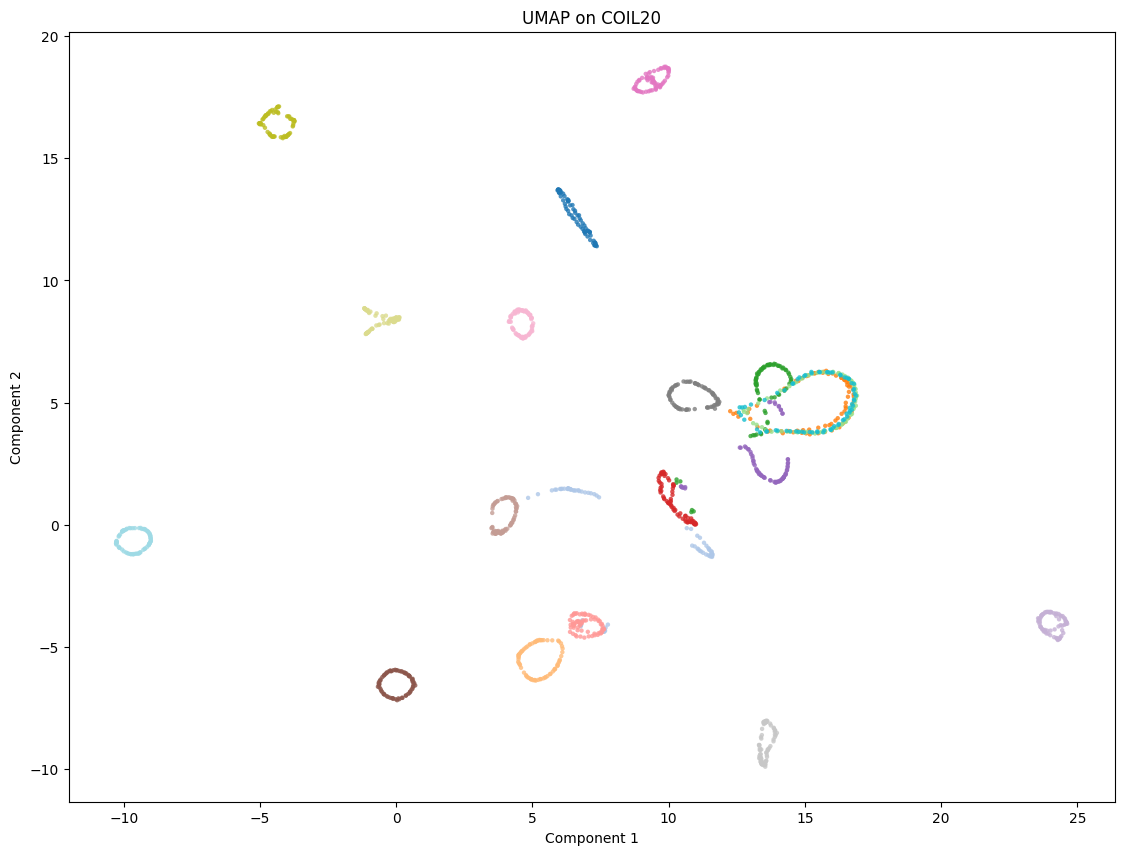

<Axes: title={'center': 'UMAP on COIL20'}, xlabel='Component 1', ylabel='Component 2'>

In [22]:
coil20_2d = umap_model.fit_transform(coil20_X)
plot_embedding_scatter(coil20_2d, coil20_y, title="UMAP on COIL20", s=10)

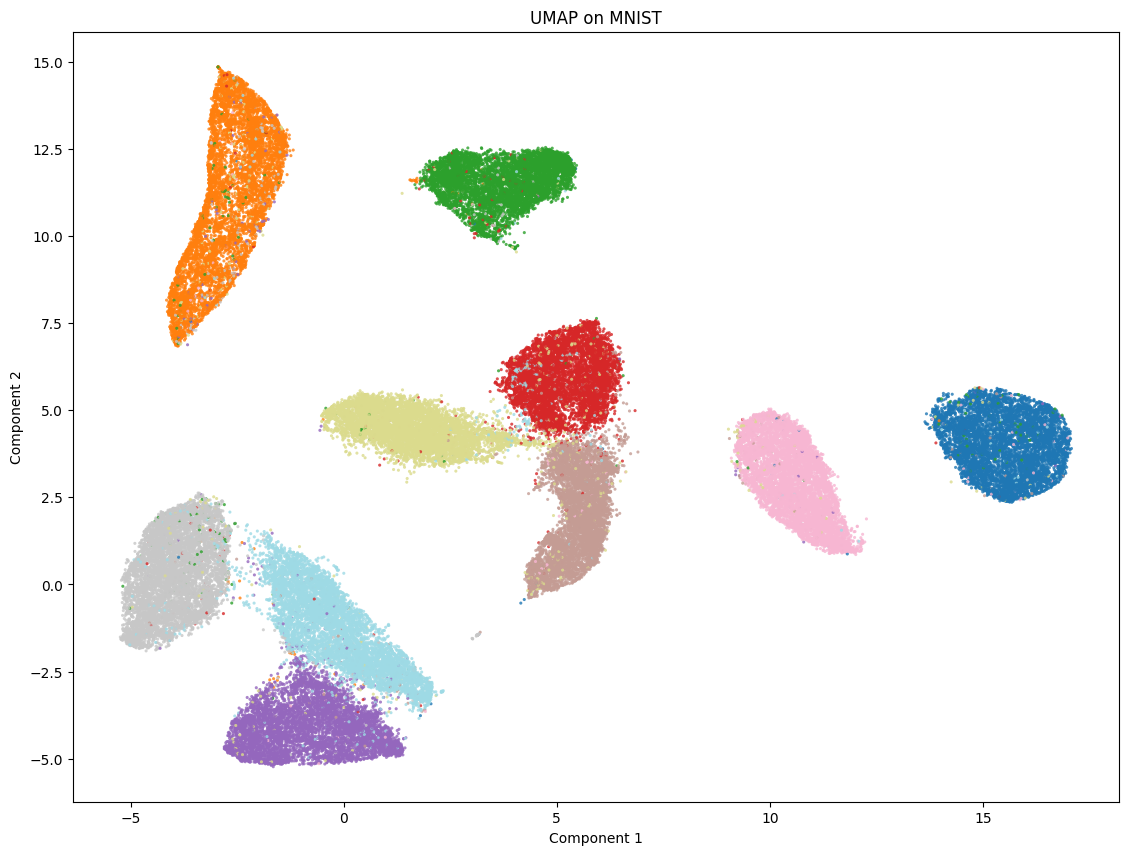

<Axes: title={'center': 'UMAP on MNIST'}, xlabel='Component 1', ylabel='Component 2'>

In [23]:
mnist_X_2d = umap_model.fit_transform(mnist_X)
plot_embedding_scatter(mnist_X_2d, mnist_y, title="UMAP on MNIST", s=5)